## Lifestyle Prediction classifier: *from Binary to Multi-Class Classification Challenges*
***final project for the AML-Basic course, Bioinformatics Unibo***

**Author: Visani Alessia**

<hr style="border: none; border-top: 3px dotted #ccc;" />

### Theorethical overview 

This notebook explores a Lifestyle Prediction Classifier, investigating how model performance and generalization capabilities shift when transitioning from a straightforward **binary classification task** (like distinguishing high-risk versus low-risk lifestyle categories) to a  **multi-class classification challenge** ( predicting specific stages of obesity and weight categories). By examining the structural distribution of features—such as dietary habits, physical activity, and demographic attributes—this study analyzes the inherent complexities, boundary overlaps, and decision-making constraints that tree-based models encounter as class granularity increases.

*PROJECTS' QUESTIONS AND AIMS:*

- **binary classification**: Can we accurately predict whether someone falls into an 'Obese' category using a binary classification approach, and is family history alone sufficient to make that prediction?
- **multi-class classification**:  Can we accurately predict an individual's obesity level category (NObeyesdad) based on their eating habits and physical condition?


> **pipeline**: import data > EDA > visualization > analytical decisions > data preprocessing > modeling > evaluation of the model > final results

#### different libraries were used in order to respond to different tasks: here is a comprehensive resume of all the ones used: 
- pandas
- numpy,
- %matplotlib inline
- matplotlib.pyplot
- seaborn
- sklearn.preprocessing : LabelEncoder
- sklearn.feature_selection : VarianceThreshold
- sklearn.model_selection : train_test_split, GridSearchCV
- sklearn.ensemble : RandomForestClassifier
- sklearn.metrics : classification_report, accuracy_score , log_loss, auc, roc_curve, ConfusionMatrixDisplay, confusion_matrix
- plotly : plotly.graph_objects, plotly.express
- sklearn.svm : SVC
- sklearn.neighbors : KNeighborsClassifier


<hr style="border: none; border-top: 3px dotted #ccc;" />

#### additional insigths
 > further analysis could be directed to treating the data to solve some regression related questions like *predicting physical activity frequency (FAF - Frequency of physical activity) based on age, mode of transportation (MTRANS), and time spent using tech devices (TUE)*

<hr style="border: none; border-top: 3px dotted #ccc;" />

### *STEP 0: import libraries and load data*

In [41]:
import pandas as pd
%matplotlib inline 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
!pip install plotly
import plotly.graph_objects as go
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import log_loss
from sklearn.metrics import auc, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [42]:
def fetchnload(data):
    mytable=pd.read_csv(data)
    return mytable

github_url="https://raw.githubusercontent.com/alessiavisani/ML-LifestylePrediction-Classifier/main/ObesityDataSet_raw_and_data_sinthetic.csv"

#creating our object
data=fetchnload(github_url)


In [43]:
#info() method is useful to get a quick description of the data, in particular the total number of rows, each attribute’s type, and the number of nonnull values

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

in our case it is possible to see that we have a total of 2111 entries divided by 17 columns; from the non-null count we see that the number is respected for each and entry moreover we observe that in general the datatype is to be divided between numbericals and object, so it
could hold any kind of Python object. But since data was loaded from a CSV file,
we know that it must be a text attribute.

### *Step 1: EDA* - exploratory data analysis

In [44]:
# inspecting out objects types
def check_object_columns(dataframe):
    
    object_cols = dataframe.select_dtypes(include=['object']).columns
    for col in object_cols:
        missing_count = dataframe[col].isna().sum()
        total_count = dataframe[col].count()
        print(f"=== Value counts for column: '{col}' ===")
        print(dataframe[col].value_counts())
        print(f"total count check: {str(total_count)}")
        print("\n" + "-"*40 + "\n")

check_object_columns(data)

=== Value counts for column: 'Gender' ===
Gender
Male      1068
Female    1043
Name: count, dtype: int64
total count check: 2111

----------------------------------------

=== Value counts for column: 'family_history_with_overweight' ===
family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64
total count check: 2111

----------------------------------------

=== Value counts for column: 'FAVC' ===
FAVC
yes    1866
no      245
Name: count, dtype: int64
total count check: 2111

----------------------------------------

=== Value counts for column: 'CAEC' ===
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64
total count check: 2111

----------------------------------------

=== Value counts for column: 'SMOKE' ===
SMOKE
no     2067
yes      44
Name: count, dtype: int64
total count check: 2111

----------------------------------------

=== Value counts for column: 'SCC' ===
SCC
no     2015
yes      96
Name: c

In [45]:
#summary for each numerical attribute 

data.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


--- **(*age*)**

Based on the output The dataset primarily represents a younger demographic, with an average age of 24.3 years and a median of 22.8 years. The middle 50% of individuals fall between roughly 19.9 and 26.0 years old, though the maximum age reaches 61 years.

--- **(*height vs weight*)**

For the physical measuraments the Weight stands out in comparison to the Height showing infact a wide dispersion ranging from 39 kg to 173 kg. The mean weight is 86.6 kg, while the median is slightly lower at 83.0 kg, pointing to a slight right-skew due to individuals in higher obesity categories.

In [46]:
# i decide to investigate the numerical values for correlation and skewness

def check_correlations_and_skew(dataframe):
    
    numeric_df = dataframe.select_dtypes(include=['float64'])
    
    print("=== SPEARMAN CORRELATION MATRIX ===")
    correlation_matrix = numeric_df.corr(method='spearman')
    print(correlation_matrix)
    print("\n" + "-"*50 + "\n")
    
    print("=== SKEWNESS OF NUMERICAL FEATURES ===")
    skew_values = numeric_df.skew()
    print(skew_values)
    
    return correlation_matrix, skew_values


corr_matrix, skews = check_correlations_and_skew(data)

=== SPEARMAN CORRELATION MATRIX ===
             Age    Height    Weight      FCVC       NCP      CH2O       FAF  \
Age     1.000000 -0.002956  0.356771  0.061594 -0.105668  0.013064 -0.208314   
Height -0.002956  1.000000  0.462548 -0.056079  0.203787  0.225237  0.325870   
Weight  0.356771  0.462548  1.000000  0.208417  0.002875  0.225592 -0.043871   
FCVC    0.061594 -0.056079  0.208417  1.000000  0.086187  0.065693  0.027688   
NCP    -0.105668  0.203787  0.002875  0.086187  1.000000  0.070227  0.144912   
CH2O    0.013064  0.225237  0.225592  0.065693  0.070227  1.000000  0.155720   
FAF    -0.208314  0.325870 -0.043871  0.027688  0.144912  0.155720  1.000000   
TUE    -0.298076  0.081548 -0.049870 -0.087514  0.087268  0.023162  0.050629   

             TUE  
Age    -0.298076  
Height  0.081548  
Weight -0.049870  
FCVC   -0.087514  
NCP     0.087268  
CH2O    0.023162  
FAF     0.050629  
TUE     1.000000  

--------------------------------------------------

=== SKEWNESS OF NUM

I chose to use the **Spearman correlation coefficient** instead of Pearson because it is better suited for non-linear data distributions. As indicated by the differences between the mean and median—along with the high skewness in columns like Age— the dataset does not follow a strict normal distribution.

While Pearson only measures *linear relationships* and can underestimate strong connections if the trend curves, Spearman evaluates *monotonic relationships* based on *ranked values*. This makes it more robust against skewed data and outliers, allowing it to capture hidden relationships—such as the stronger correlation observed between age and weight—that a linear coefficient might miss.

---

### *Step 2: some visualization*

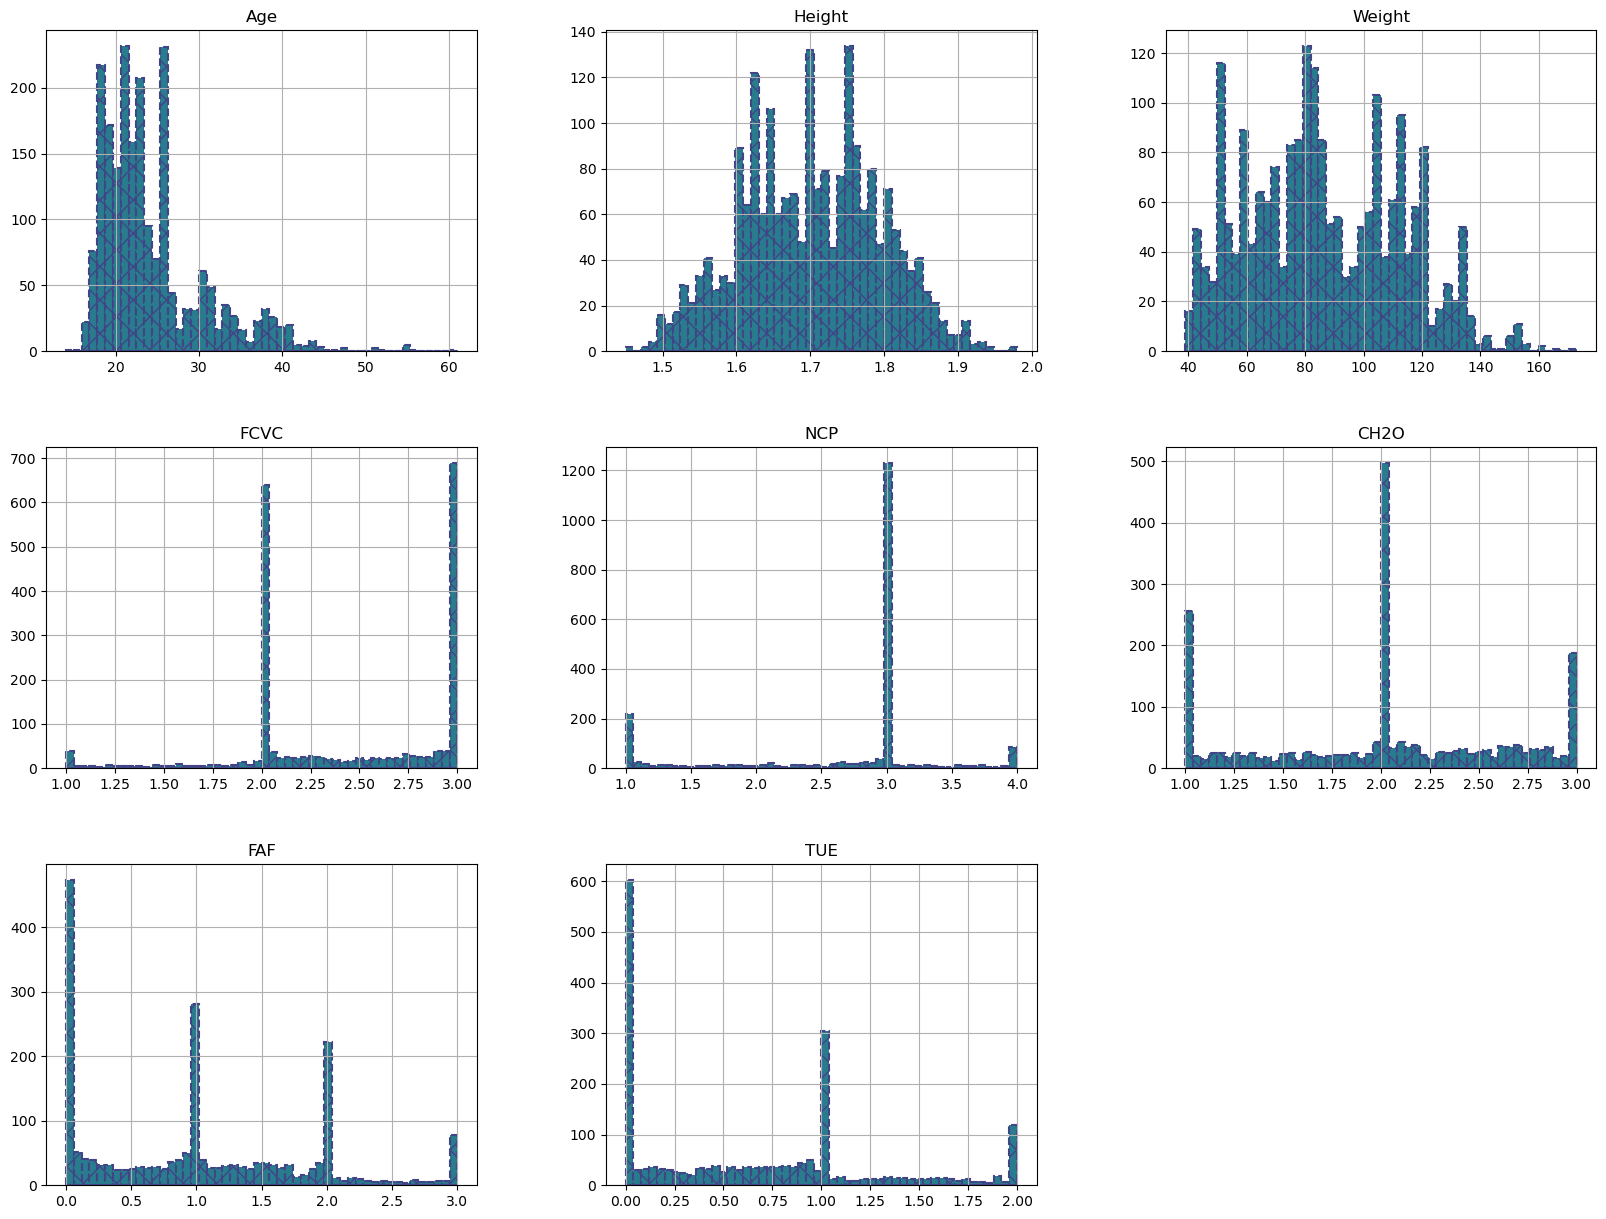

In [47]:
#further investigating skewness using histograms

data.hist(bins=50, figsize=(20,15),color='#287C8EFF', edgecolor='#414487FF', linewidth=1.5, linestyle='--',hatch='x')
plt.show()



**commenting the plots:** 
as we can see from the histogram plots generated above as aforementioned earlier some variables like age and weight do not follow a standard Gaussian rather a type of Gumbell distirbution; hence to limit skeweness of further results and analytical choices different types of non-parametric statistical techniques are being put to use. 

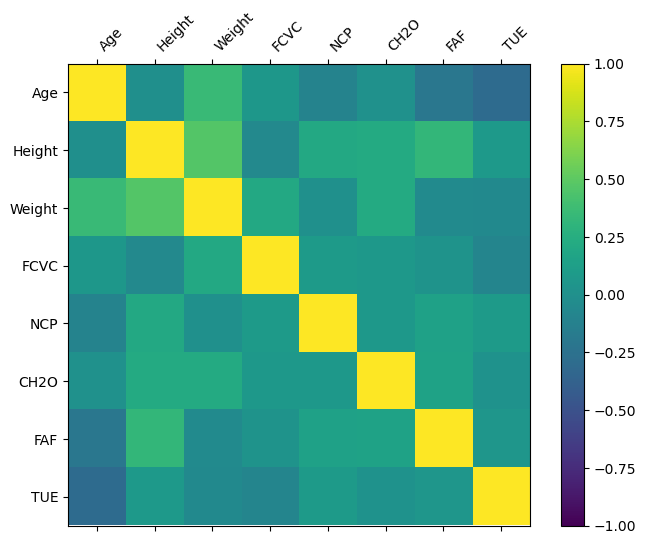

In [48]:
#correlation matrix plot
numeric_df = data.select_dtypes(include=['float64'])
names = list(numeric_df.columns)

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr_matrix, vmin=-1, vmax=1, cmap='viridis')
fig.colorbar(cax)


ticks = np.arange(0, len(names), 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)


ax.set_xticklabels(names, rotation=45, ha='left')
ax.set_yticklabels(names)

plt.show()

**note:** the correlation matrix highlights the presence of variables correlated to one another. In our interest we see that Weight-Age and Weight-Height are tightly correlated therefore careful choices are to be made in order to account for the relatedness of data.

---

### *Step 3: analytical decisions*

To properly address both research objectives, the workflow branches during the analytical decisions phase into two distinct dataset versions: one optimized for binary classification and another for multi-class classification. This approach allows the target variable (NObeyesdad) to be explicitly transformed for each context—collapsing into a two-class label for the binary task while preserving core categories for the multi-class task. By maintaining separate data pipelines, we ensure that subsequent modeling and evaluation accurately reflect how tree-based algorithms handle varying degrees of class complexity without cross-contamination or data leakage.

#### creating the binary dataset
For the binary classification pipeline, the target variable NObeyesdad is mapped using strict clinical guidelines. Individuals classified under Obesity Type I, Type II, and Type III are grouped into the positive class (1), representing clinically diagnosed obesity (BMI≥30). Conversely, individuals categorized as Underweight, Normal Weight, and Overweight are grouped into the negative class (0). This establishes a definitive medical boundary, allowing us to evaluate how effectively tree-based models can separate high-risk obese individuals from the rest of the population using behavioral and lifestyle features.

In [49]:

data_binary = data.copy()
cols_to_drop = ['Height', 'Weight']
data_binary=data_binary.drop(columns=cols_to_drop, errors='ignore')

#clinical obesity categories (BMI >= 30)
strict_obese_classes = [
    'Obesity_Type_I', 
    'Obesity_Type_II', 
    'Obesity_Type_III'
]

#appling the binary classification
data_binary['NObeyesdad'] = data_binary['NObeyesdad'].apply(
    lambda x: 1 if x in strict_obese_classes else 0
)

# Verify the new binary distribution
print("Strict Clinical Binary Target Distribution:")
print(data_binary['NObeyesdad'].value_counts(normalize=True) * 100)


Strict Clinical Binary Target Distribution:
NObeyesdad
0    53.955471
1    46.044529
Name: proportion, dtype: float64


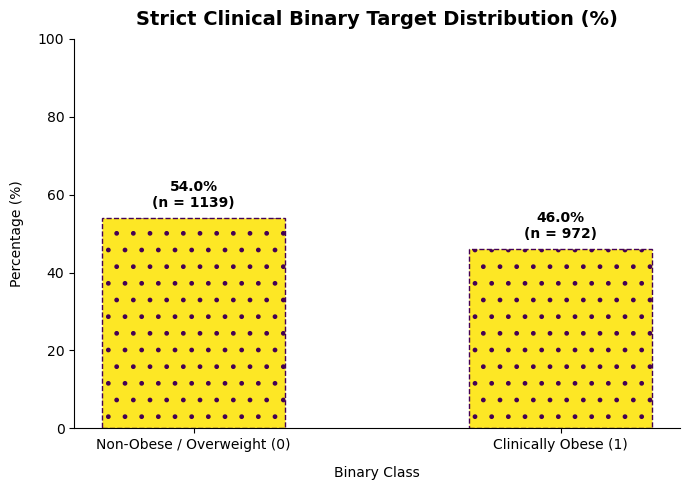

In [50]:
#visualization of data_binary new NObeyesdad
total = len(data_binary)
counts = data_binary['NObeyesdad'].value_counts().sort_index()
percentages = (counts / total) * 100


plt.figure(figsize=(7, 5))

# Create standard matplotlib bar chart
bars = plt.bar(
    ['Non-Obese / Overweight (0)', 'Clinically Obese (1)'], 
    percentages, 
    color='#FDE725FF',                  
    edgecolor='#440154FF',        
    linestyle='--',
    hatch='.',
    width=0.5,

)

plt.title('Strict Clinical Binary Target Distribution (%)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Binary Class', fontsize=10, labelpad=10)
plt.ylabel('Percentage (%)', fontsize=10, labelpad=10)
plt.ylim(0, 100)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = height
    label_text = f'{percentage:.1f}%\n(n = {int(count)})'
    
    plt.annotate(
        label_text, 
        (bar.get_x() + bar.get_width() / 2., height), 
        ha='center', va='bottom', 
        xytext=(0, 6), 
        textcoords='offset points', 
        fontsize=10, fontweight='bold'
    )

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### creating the multi-class dataset

Dropping height and weight from the multi-class feature set is a crucial analytical decision designed to prevent data leakage and preserve the integrity of the research question. Because the target variable (NObeyesdad) is mathematically derived directly from Body Mass Index (BMI)—which is calculated using an individual's height and weight—retaining these physical measurements would provide the model with an artificial shortcut. Instead of learning patterns from behavioral and lifestyle attributes, tree-based algorithms would instantly rely on these direct physical metrics to near-perfect accuracy. Removing height and weight ensures that the model is genuinely tested on its ability to predict distinct weight categories based solely on demographics, dietary habits, and lifestyle factors.

In [51]:

data_multiclass = data.copy()

#Drop Height and Weight
cols_to_drop = ['Height', 'Weight']
data_multiclass = data_multiclass.drop(columns=cols_to_drop, errors='ignore')


print("Features included in multi-class dataset:")
print(data_multiclass.columns.tolist())
#verifying integrity
data_multiclass.shape


Features included in multi-class dataset:
['Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


(2111, 15)

#### Feature econding

Categorical encoding is a critical preprocessing step in machine learning because algorithms—particularly tree-based models and regressions—require numerical input to perform mathematical computations and split nodes effectively. Since real-world datasets frequently contain text-based attributes such as gender, transportation methods, or dietary frequencies, leaving these values unencoded prevents models from parsing the data entirely. By transforming categorical variables into structured numerical formats (such as through one-hot or label encoding), I ensured that all relevant behavioral and demographic information was accurately translated into a format the model could evaluate. 

In [52]:

obesity_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}


if data_multiclass['NObeyesdad'].dtype == 'object':
    data_multiclass['NObeyesdad'] = data_multiclass['NObeyesdad'].map(obesity_mapping)
    print("Successfully mapped multi-class target to integers!")
else:
    print("Target is already encoded. Skipping to prevent corruption.")

if data_binary['NObeyesdad'].dtype == 'object':
    data_binary['NObeyesdad'] = data_binary['NObeyesdad'].map(obesity_mapping)
else:
    print("Target is already encoded. Skipping to prevent corruption.")



# Quick verification
print("\nEncoded binary Target Distribution:")
print(data_binary['NObeyesdad'].value_counts())

# Quick verification
print("\nEncoded multiclass Target Distribution:")
print(data_multiclass['NObeyesdad'].value_counts())


# dropping NObeyesdad because is our target Y

# For Binary Dataset Features:
X_binary = data_binary.drop(columns=['NObeyesdad'])
y_binary = data_binary['NObeyesdad']
X_binary_encoded = pd.get_dummies(X_binary, drop_first=True)

# For Multi-Class Dataset Features:
X_multiclass = data_multiclass.drop(columns=['NObeyesdad'])
y_multiclass = data_multiclass['NObeyesdad']
X_multiclass_encoded = pd.get_dummies(X_multiclass, drop_first=True)

print("\nBinary encoded feature shape:", X_binary_encoded.shape)
print("Multi-class encoded feature shape:", X_multiclass_encoded.shape)

#print to see
#X_binary_encoded.head()
#X_multiclass_encoded.head()

Successfully mapped multi-class target to integers!
Target is already encoded. Skipping to prevent corruption.

Encoded binary Target Distribution:
NObeyesdad
0    1139
1     972
Name: count, dtype: int64

Encoded multiclass Target Distribution:
NObeyesdad
4    351
6    324
5    297
2    290
3    290
1    287
0    272
Name: count, dtype: int64

Binary encoded feature shape: (2111, 21)
Multi-class encoded feature shape: (2111, 21)


---

#### Some controls for feature encoding

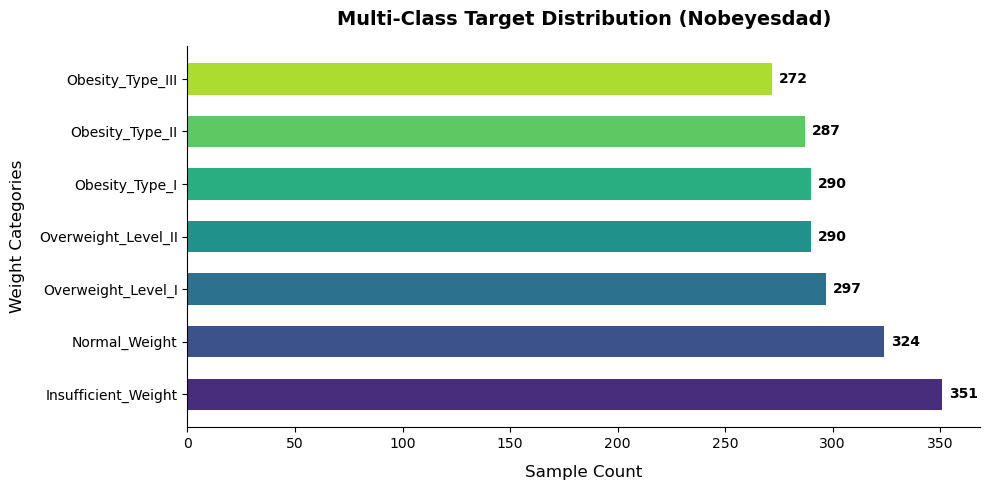

In [53]:

counts_b=data_multiclass['NObeyesdad'].value_counts()
category_names = list(obesity_mapping.keys())
colors = sns.color_palette('viridis', n_colors=len(category_names))


plt.figure(figsize=(10, 5))
bars = plt.barh(category_names, counts_b, color=colors, height=0.6)
plt.title('Multi-Class Target Distribution (Nobeyesdad)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sample Count', fontsize=12, labelpad=10)
plt.ylabel('Weight Categories', fontsize=12, labelpad=10)


for bar in bars:
    width = bar.get_width()
    plt.annotate(
        f'{int(width)}',
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),  
        textcoords='offset points',
        ha='left', va='center',
        fontsize=10, fontweight='bold'
    )

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


here i visualize that my target is well distributed across all of the categories inside the *NObeyesdad column*



In [54]:
X_multiclass_encoded.head()

,Age,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,FAVC_yes,CAEC_Frequently,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,2.0,3.0,2.0,0.0,1.0,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
1,21.0,3.0,3.0,3.0,3.0,0.0,False,True,False,False,...,False,True,True,False,True,False,False,False,True,False
2,23.0,2.0,3.0,2.0,2.0,1.0,True,True,False,False,...,False,False,False,True,False,False,False,False,True,False
3,27.0,3.0,3.0,2.0,2.0,0.0,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,22.0,2.0,1.0,2.0,0.0,0.0,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In addition, i look at the output of the *X_multiclass_encoded* dataset and realize that after get_dummies() has converted continous features into binary boolean ones i'm now interested in understanding how much variance there is within single variables like for example Means of transportation; for this reason i revert to the original dataset before feature encoding for better visualization purposes and plot

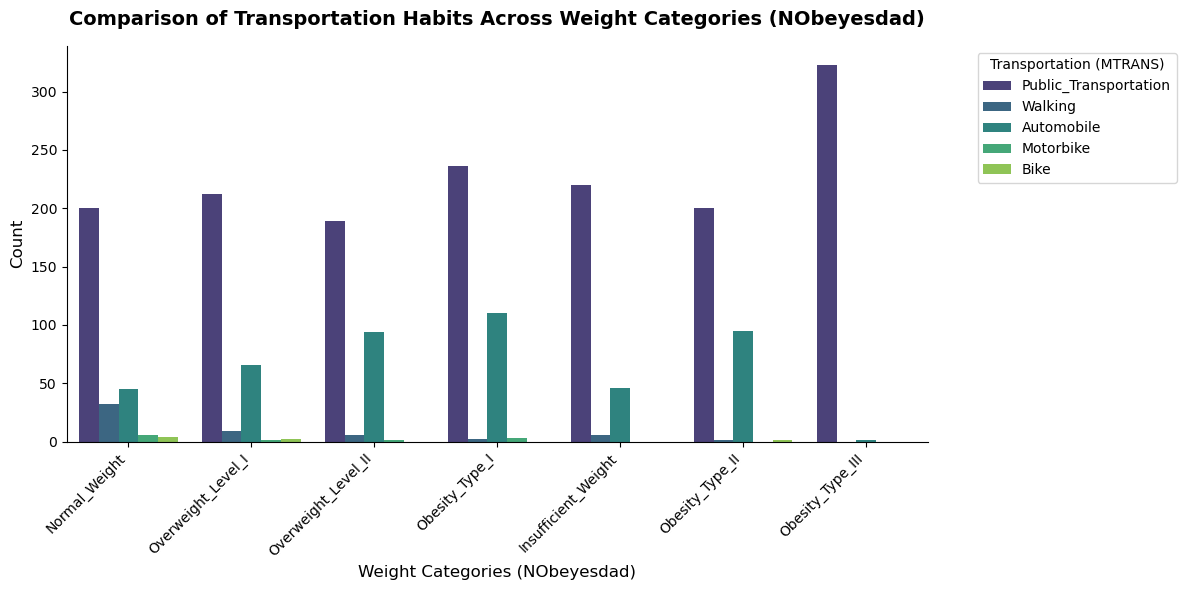

In [55]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=data,  
    x='NObeyesdad',
    hue='MTRANS',
    palette='viridis'
)

plt.title('Comparison of Transportation Habits Across Weight Categories (NObeyesdad)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Weight Categories (NObeyesdad)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.legend(title='Transportation (MTRANS)', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

thanks to analysis i'm able to understand that i should discard inside variables which introduce background noise inside my X_multiclass_encoded ans well as for my X_binary_encoded datasets before training my model; whereas for already present continous values i check that the variance within the variable is informative enough for the model to maintain its discriminative power 

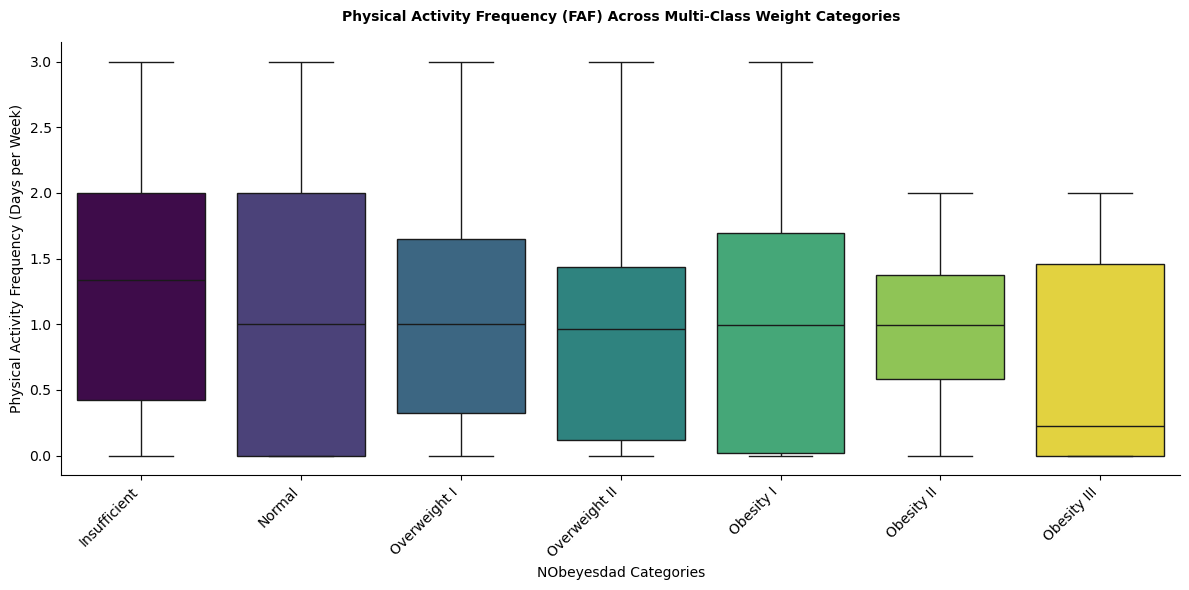

In [56]:

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='NObeyesdad', 
    y='FAF', 
    data=data_multiclass, 
    palette='viridis',
    hue='NObeyesdad',
    legend=False
)

plt.title('Physical Activity Frequency (FAF) Across Multi-Class Weight Categories', fontsize=10, fontweight='bold', pad=15)
plt.xlabel('NObeyesdad Categories', fontsize=10)
plt.ylabel('Physical Activity Frequency (Days per Week)', fontsize=10)
plt.xticks(
    ticks=[0, 1, 2, 3, 4, 5, 6], 
    labels=['Insufficient', 'Normal', 'Overweight I', 'Overweight II', 'Obesity I', 'Obesity II', 'Obesity III'], 
    rotation=45, ha='right'
)

sns.despine()
plt.tight_layout()
plt.show()

---

### Step 4: Preprocessing before modeling - applying a variance threshold of 0.5
Preprocessing data often involves filtering out uninformative features to reduce noise and improve model efficiency. By applying a Variance Threshold with a specific cutoff (like 0.05), I was able to automatically drop columns and one-hot encoded features where the vast majority of values are identical, meaning they lacked the variability needed to help my machine learning algorithms learn meaningful patterns. This technique ensured that sparse or near-constant features —such as rarely used transportation categories— were safely removed, resulting in a cleaner, lower-dimensional dataset ready for training.


In [57]:
# This will drop columns where 95% or more of the values are the same
#Binary dataset
selector1 = VarianceThreshold(threshold=0.05) 
X_binary_filtered=selector1.fit_transform(X_binary_encoded)
kept_columns_bin=X_binary_encoded.columns[selector1.get_support()]
X_binary_encoded=pd.DataFrame(X_binary_filtered,columns=kept_columns_bin)


#multiclass dataset
selector2 = VarianceThreshold(threshold=0.05)
X_multiclass_filtered = selector2.fit_transform(X_multiclass_encoded)
kept_columns_multi = X_multiclass_encoded.columns[selector2.get_support()]
X_multiclass_encoded = pd.DataFrame(X_multiclass_filtered, columns=kept_columns_multi)


In [58]:

X_binary_encoded.head()

,Age,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,FAVC_yes,CAEC_Frequently,CAEC_Sometimes,CALC_Sometimes,CALC_no,MTRANS_Public_Transportation
0,21.0,2.0,3.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
1,21.0,3.0,3.0,3.0,3.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
2,23.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,27.0,3.0,3.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,22.0,2.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0


In [59]:
X_multiclass_encoded.head()

,Age,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,FAVC_yes,CAEC_Frequently,CAEC_Sometimes,CALC_Sometimes,CALC_no,MTRANS_Public_Transportation
0,21.0,2.0,3.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
1,21.0,3.0,3.0,3.0,3.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
2,23.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,27.0,3.0,3.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,22.0,2.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0


In [60]:
X_binary_encoded['MTRANS_Public_Transportation'].value_counts()
#walinkg and bike have been discarded 
#public transportation = 1.0 
#automobile+motorbike = 0.0

MTRANS_Public_Transportation
1.0    1580
0.0     531
Name: count, dtype: int64

In [61]:
X_binary_encoded['FAVC_yes'].value_counts()


FAVC_yes
1.0    1866
0.0     245
Name: count, dtype: int64

---


### Step 5: Modeling

**performing train-test splits**

When splitting my dataset, I configured *test_size=0.2* to ensure my model learns from a robust 80% of the data while saving a dedicated 20% to fairly evaluate its performance on unseen records. To keep my experimentation consistent and reproducible across different runs, I set *random_state=42* so the random shuffling always selects the exact same rows. Finally, I included *stratify=y* to maintain the precise class distribution of my target variable in both subsets, ensuring my model trains and tests on balanced proportions rather than accidentally skewing the evaluation metrics.

In [62]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary_encoded, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multiclass_encoded, y_multiclass, test_size=0.2, random_state=42, stratify=y_multiclass
)

***Training the binary model***

In [63]:
rf_bin = RandomForestClassifier(random_state=42)
rf_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = rf_bin.predict(X_test_bin)

print("--- BINARY CLASSIFICATION RESULTS RANDOM FOREST ---")
print("Accuracy:", accuracy_score(y_test_bin, y_pred_bin))
print(classification_report(y_test_bin, y_pred_bin))

--- BINARY CLASSIFICATION RESULTS RANDOM FOREST ---
Accuracy: 0.933806146572104
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       228
           1       0.94      0.91      0.93       195

    accuracy                           0.93       423
   macro avg       0.93      0.93      0.93       423
weighted avg       0.93      0.93      0.93       423



In [64]:
# Isolating ONLY family history as the single feature
X_train_single = X_train_bin[['family_history_with_overweight_yes']]
X_test_single = X_test_bin[['family_history_with_overweight_yes']]


rf_single = RandomForestClassifier(random_state=42)
rf_single.fit(X_train_single, y_train_bin)
y_pred_single = rf_single.predict(X_test_single)


print("--- RESULTS USING ONLY FAMILY HISTORY ---")
print("Accuracy:", accuracy_score(y_test_bin, y_pred_single))
print(classification_report(y_test_bin, y_pred_single))

--- RESULTS USING ONLY FAMILY HISTORY ---
Accuracy: 0.624113475177305
              precision    recall  f1-score   support

           0       0.99      0.31      0.47       228
           1       0.55      0.99      0.71       195

    accuracy                           0.62       423
   macro avg       0.77      0.65      0.59       423
weighted avg       0.79      0.62      0.58       423



In [65]:
#!pip install plotly

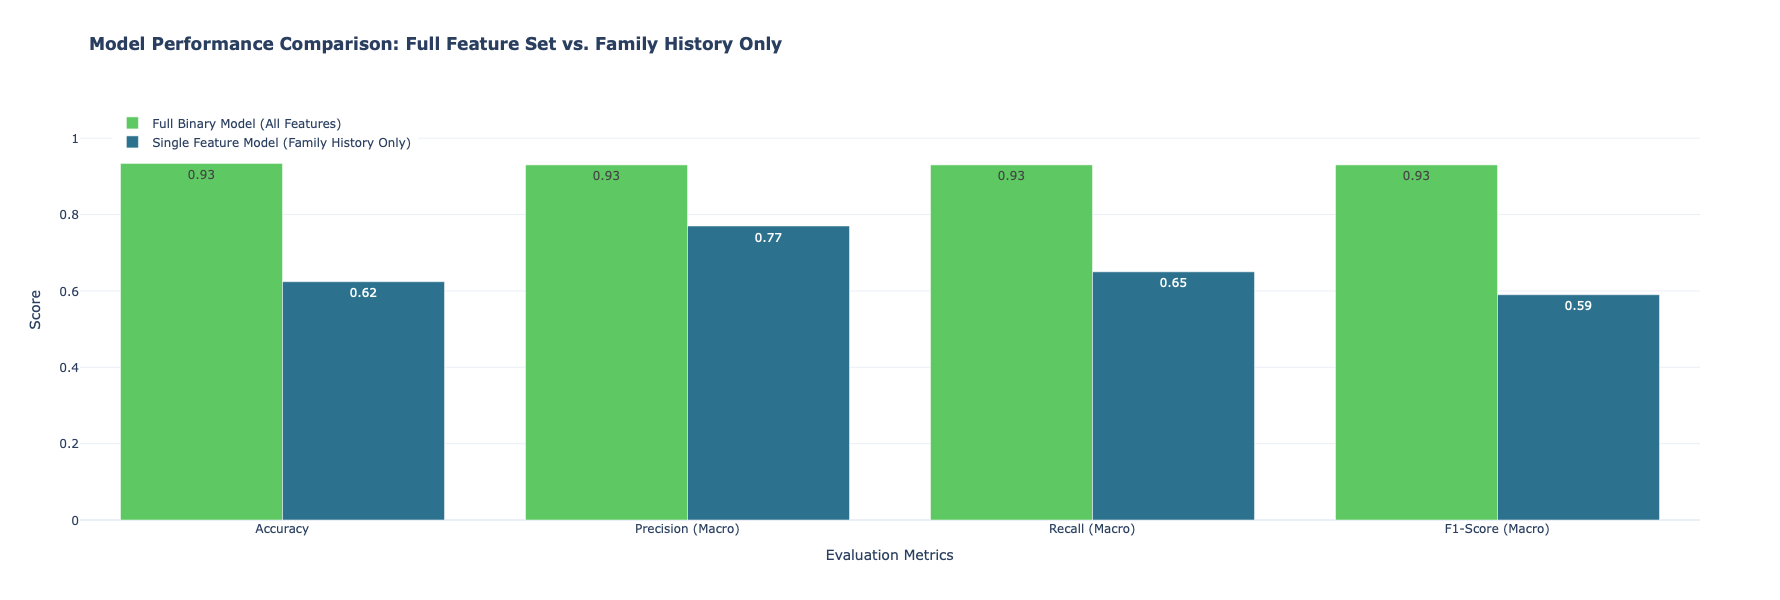

In [66]:

metrics = [
    'Accuracy',
    'Precision (Macro)',
    'Recall (Macro)',
    'F1-Score (Macro)',
]

full_model_scores = [0.9338, 0.93, 0.93, 0.93]  # From Full Binary Model results
single_model_scores = [
    0.6241,
    0.77,
    0.65,
    0.59,
]  # From Family History Only results

fig = go.Figure()

fig.add_trace(
    go.Bar(
        name='Full Binary Model (All Features)',
        x=metrics,
        y=full_model_scores,
        marker_color='#5ec962',
        text=[f'{val:.2f}' for val in full_model_scores],
        textposition='auto',
    )
)

fig.add_trace(
    go.Bar(
        name='Single Feature Model (Family History Only)',
        x=metrics,
        y=single_model_scores,
        marker_color='#2C728EFF',
        text=[f'{val:.2f}' for val in single_model_scores],
        textposition='auto',
    )
)

fig.update_layout(
    title=(
        '<b>Model Performance Comparison: Full Feature Set vs. Family History'
        ' Only</b>'
    ),
    xaxis_title='Evaluation Metrics',
    yaxis_title='Score',
    barmode='group',
    yaxis=dict(range=[0, 1.1]),
    template='plotly_white',
    height=600,
    legend=dict(x=0.02, y=0.98),
)

fig.show()

> Analysis of Family History as a Single Predictor

To test our core research question— *can we predict obesity categories solely based on family history?* —we trained a dedicated model using only the `family_history_with_overweight_yes` feature.

* **Comparison with Full Model:** While the full feature model achieved a strong accuracy of **93.3%**, the single-feature model using only family history dropped significantly to an accuracy of **62.4%**.
* **Precision and Recall Trade-off:** The model trained solely on family history heavily over-predicts obesity (class 1), achieving a high recall of `0.99` but a very low precision of `0.55` for that class. Conversely, its ability to correctly identify non-obese individuals (class 0) suffers with a recall of only `0.31`.
* **Conclusion:** Family history alone is insufficient for accurate prediction. While it provides a baseline genetic risk signal, reliably predicting obesity requires combining genetic factors with lifestyle, diet, and physical habits.

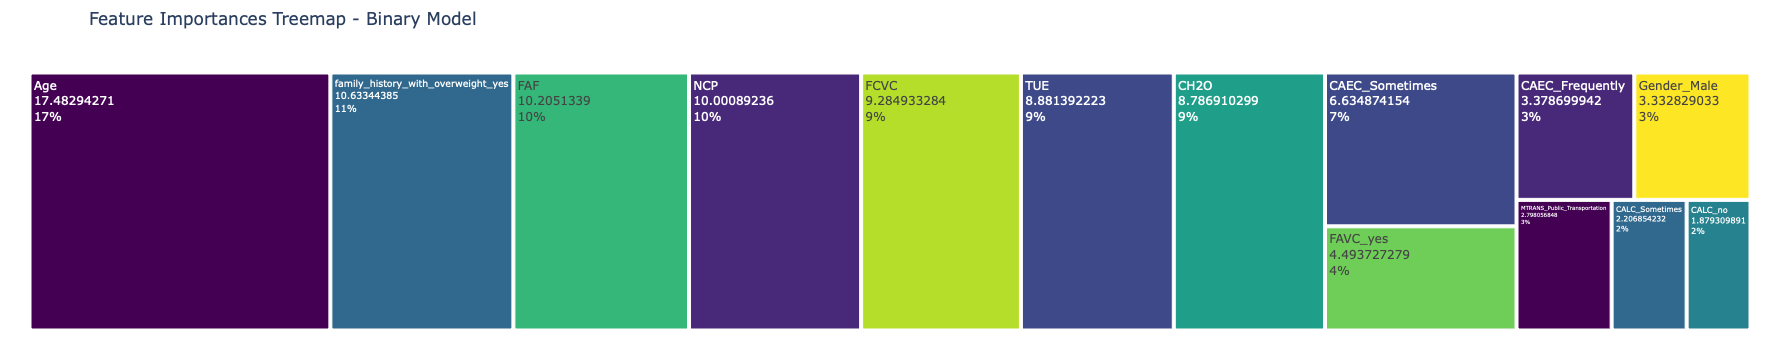

In [67]:

bin_importances = (pd.Series(rf_bin.feature_importances_, index=X_binary_encoded.columns)*100).sort_values(ascending=False)

df_treemap = pd.DataFrame({
    'Feature': bin_importances.index,
    'Importance': bin_importances.values,
})


fig = px.treemap(
    df_treemap,
    path=['Feature'],
    values='Importance',  
    color='Feature', 
    color_discrete_sequence=px.colors.sequential.Viridis,
    
)


fig.update_traces(
    root_color="white",
    textinfo='label+value+percent parent',
    hovertemplate='<b>%{label}</b><br>Importance Score: %{value:.2f}%<br>(%{percentParent} of total)',
    
)

fig.update_layout(
    title_text='Feature Importances Treemap - Binary Model',
    margin=dict(t=50, l=25, r=25, b=25),
)

fig.show()

#print("\nBinary Model Importances:")
#print(bin_importances)

***Training the multiclass model***

In [68]:
rf_multi = RandomForestClassifier(random_state=42)
rf_multi.fit(X_train_multi, y_train_multi)
y_pred_multi = rf_multi.predict(X_test_multi)

print("\n--- MULTI-CLASS CLASSIFICATION RESULTS ---")
print("Accuracy:", accuracy_score(y_test_multi, y_pred_multi))
print(classification_report(y_test_multi, y_pred_multi))


--- MULTI-CLASS CLASSIFICATION RESULTS ---
Accuracy: 0.8297872340425532
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        54
           1       0.65      0.72      0.68        58
           2       0.71      0.71      0.71        58
           3       0.80      0.76      0.78        58
           4       0.83      0.79      0.81        70
           5       0.90      0.93      0.92        60
           6       1.00      0.97      0.98        65

    accuracy                           0.83       423
   macro avg       0.83      0.83      0.83       423
weighted avg       0.83      0.83      0.83       423



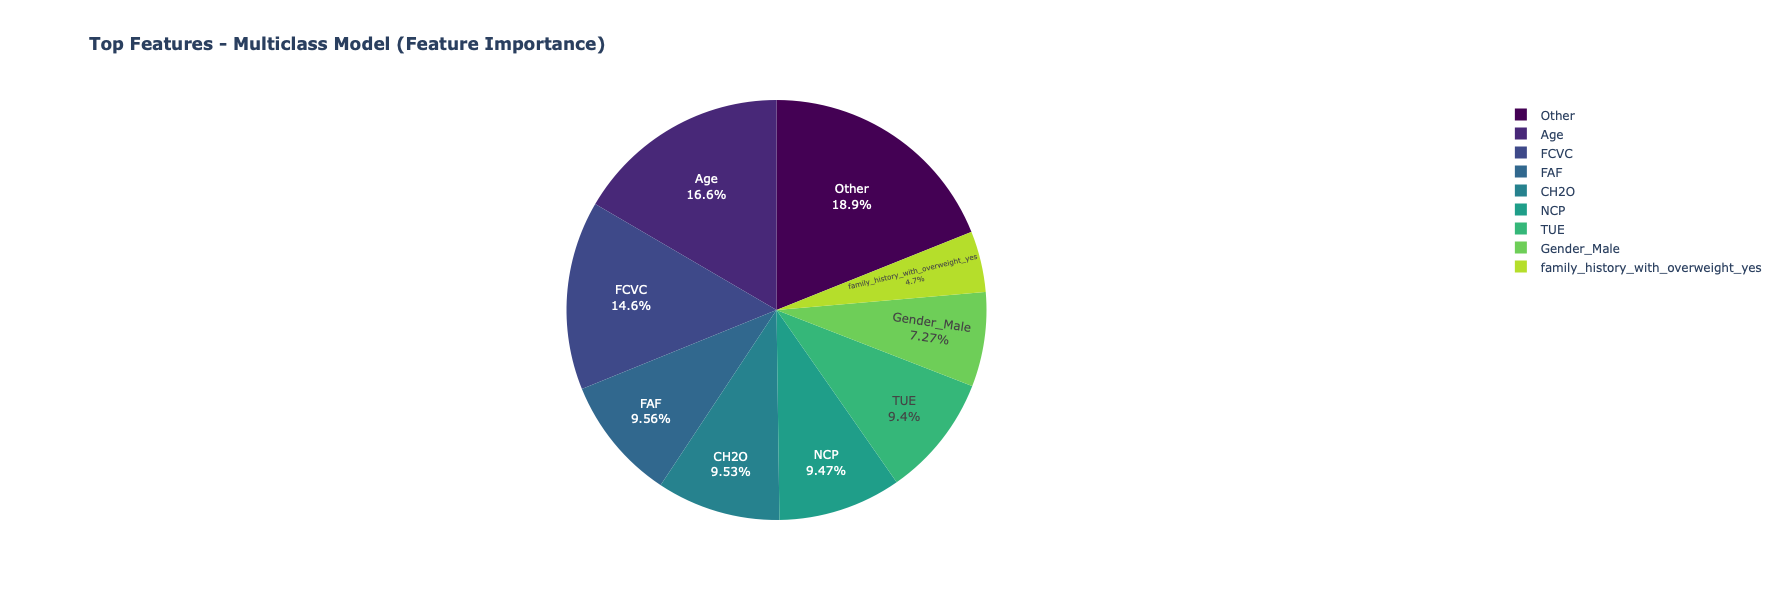

In [69]:


multi_importances = (pd.Series(rf_multi.feature_importances_, index=X_multiclass_encoded.columns) * 100).sort_values(ascending=False)


threshold = 4.0
main_features = multi_importances[multi_importances >= threshold]
other_sum = multi_importances[multi_importances < threshold].sum()

if other_sum > 0:
    pie_data = pd.concat([main_features, pd.Series({'Other': other_sum})])
else:
    pie_data = main_features

# convert Series to a DataFrame for Plotly Express
df_pie = pie_data.reset_index()
df_pie.columns = ['Feature', 'Importance']



fig = px.pie(
    df_pie, 
    values='Importance', 
    names='Feature',
    title='<b>Top Features - Multiclass Model (Feature Importance)</b>',
    color_discrete_sequence=px.colors.sequential.Viridis
      # Optional: Turns it into a modern Donut chart (remove if you want a full pie)
)


fig.update_traces(
    textposition='inside', 
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>Importance: %{value:.2f}%<extra></extra>'
)

fig.update_layout(
    template='plotly_white',
    height=600
)

fig.show()

# Print raw feature 
#print(multi_importances)

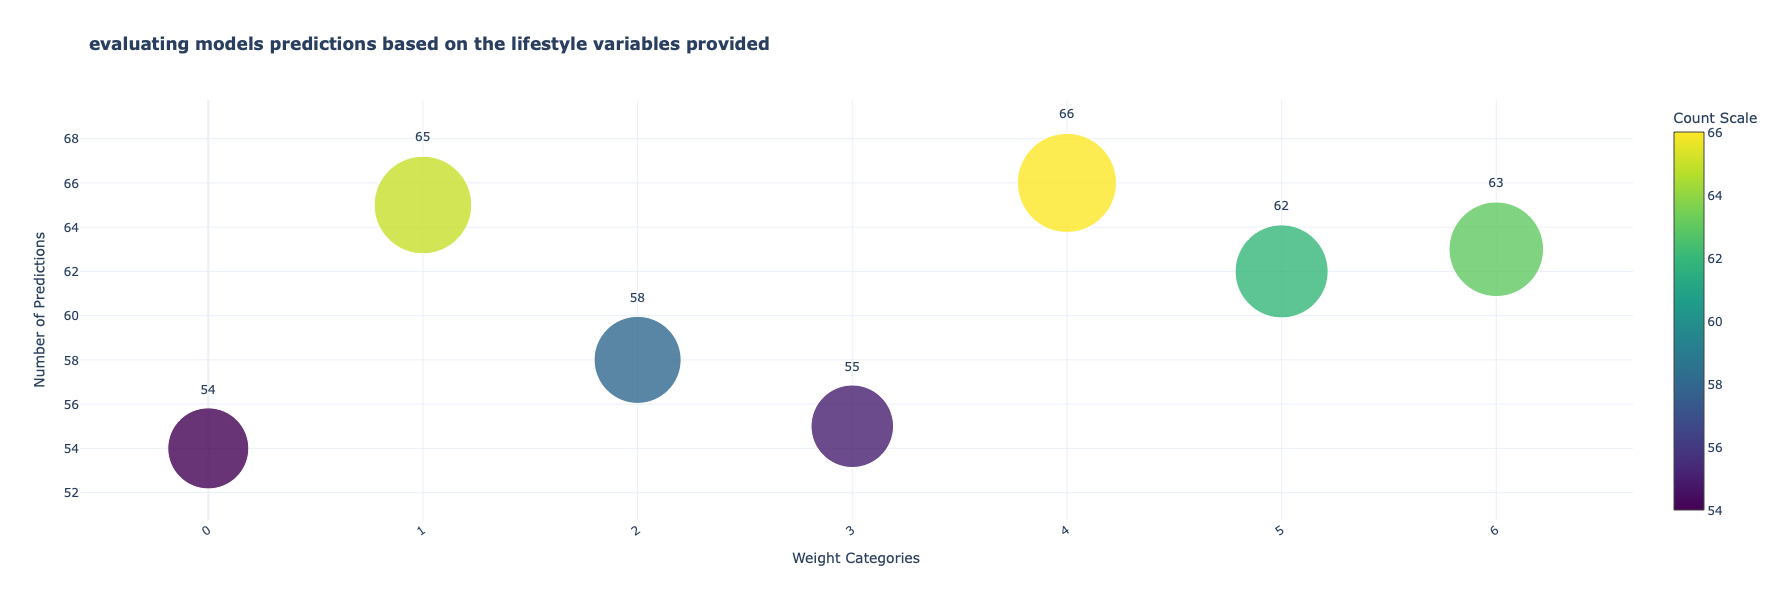

In [70]:


classes_count = pd.Series(y_pred_multi).value_counts().reset_index()
classes_count.columns = ['Category', 'Count']




fig = go.Figure(data=[go.Scatter(
    x=classes_count['Category'],
    y=classes_count['Count'],
    mode='markers+text',
    hovertemplate='<b>%{x}</b><extra></extra>',
    text=classes_count['Count'], 
    textposition='top center',
    marker=dict(
        color=classes_count['Count'],      
        size=classes_count['Count'] * 1.5,  
        colorscale='Viridis',               
        showscale=True,
        colorbar=dict(title='Count Scale'),
        opacity=0.8
    )
)])

# 3. Customize layout
fig.update_layout(
    title='<b>evaluating models predictions based on the lifestyle variables provided</b>',
    xaxis_title='Weight Categories',
    yaxis_title='Number of Predictions',
    xaxis=dict(tickangle=-35),
    template='plotly_white',
    height=600
)

fig.show()

---

### Step 6 - Evaluation of the model

**BINARY MODEL EVALUATION**

In [71]:
#firstly i would like to compare the algorithm i have chosen to different types of algorithms 

#Scale the data (Mandatory for SVMs and k-NN)
scaler = StandardScaler()
X_train_bin_scaled = scaler.fit_transform(X_train_bin)
X_test_bin_scaled = scaler.transform(X_test_bin)

#Train the model Support vector machine
svm_bin = SVC(kernel='rbf', probability=True, random_state=42)
svm_bin.fit(X_train_bin_scaled, y_train_bin)
#Train the model k-nearest neighbor
knn_bin = KNeighborsClassifier(n_neighbors=5)
knn_bin.fit(X_train_bin_scaled, y_train_bin)

#Generate predictions
y_pred_svm_bin = svm_bin.predict(X_test_bin_scaled)

y_pred_knn_bin = knn_bin.predict(X_test_bin_scaled)
y_proba_knn_bin = knn_bin.predict_proba(X_test_bin_scaled)



print("--- SUPPORT VECTOR MACHINE (BINARY) RESULTS ---")
print("Accuracy:", accuracy_score(y_test_bin, y_pred_svm_bin))
print(classification_report(y_test_bin, y_pred_svm_bin))



print('--- K-NEAREST NEIGHBORS (BINARY) RESULTS ---')
print("Accuracy:", accuracy_score(y_test_bin, y_pred_knn_bin))
print(classification_report(y_test_bin, y_pred_knn_bin))

--- SUPPORT VECTOR MACHINE (BINARY) RESULTS ---
Accuracy: 0.8699763593380615
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       228
           1       0.84      0.89      0.86       195

    accuracy                           0.87       423
   macro avg       0.87      0.87      0.87       423
weighted avg       0.87      0.87      0.87       423

--- K-NEAREST NEIGHBORS (BINARY) RESULTS ---
Accuracy: 0.900709219858156
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       228
           1       0.90      0.88      0.89       195

    accuracy                           0.90       423
   macro avg       0.90      0.90      0.90       423
weighted avg       0.90      0.90      0.90       423



--- comparison of the results achieved with Random Forest, Support Vector Machines and K - Nearest Neighbor ---

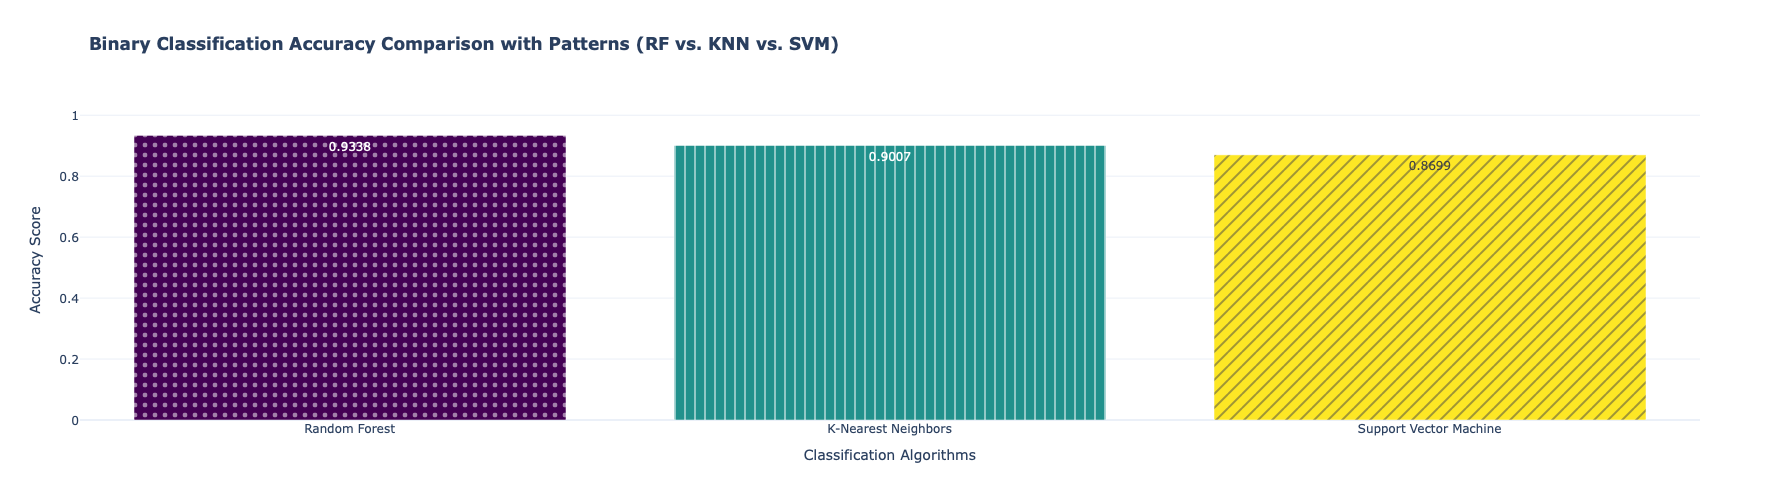

In [72]:
models = ["Random Forest", "K-Nearest Neighbors", "Support Vector Machine"]
accuracies = [0.9338, 0.9007, 0.8699]
colors = ["#440154", "#21918c", "#fde725"] 

patterns = [".", "|", "/"]

fig = go.Figure()

for model, acc, col, pat in zip(models, accuracies, colors, patterns):
  fig.add_trace(
      go.Bar(
          name=model,
          x=[model],
          y=[acc],
          marker=dict(
              color=col,
              pattern=dict(
                  shape=pat, fillmode="overlay"
              ),  
          ),
          text=[f"{acc:.4f}"],
          textposition="auto",
      )
  )

fig.update_layout(
    title=(
        "<b>Binary Classification Accuracy Comparison with Patterns (RF vs."
        " KNN vs. SVM)</b>"
    ),
    xaxis_title="Classification Algorithms",
    yaxis_title="Accuracy Score",
    yaxis=dict(range=[0, 1.05]),
    template="plotly_white",
    height=500,
    showlegend=False,
)

fig.show()

***calculating the log loss on the variable ['family_history_overweight_yes'] in the full binary model***

Logarithmic loss (or log-loss) is a performance metric used to evaluate the predicted probabilities of a given class membership. The resulting probability score between 0 and 1 serves as a measure of algorithmic confidence, where correct or incorrect predictions are rewarded or punished proportionally to that confidence. As we have seen, isolating a single predictor—such as family_history_overweight_yes—to build a Random Forest model yields a poor accuracy of about 0.65. I am now interested in determining how much entropy (or information gain) this specific variable contributes when we evaluate the log-loss of our full binary model incorporating all features.

In [73]:
# --- FULL BINARY MODEL (All Features) ---
y_pred_proba_bin = rf_bin.predict_proba(X_test_bin)[:, 1]
print('Log Loss full binary model:', log_loss(y_test_bin, y_pred_proba_bin))

# --- SINGLE FEATURE MODEL (Family History Only) ---
y_pred_proba_single = rf_single.predict_proba(X_test_single)[:, 1]
print('Log Loss single feature:', log_loss(y_test_bin, y_pred_proba_single))


Log Loss full binary model: 0.23055963726199516
Log Loss single feature: 0.5852706859961572


Comparing the log loss metrics reveals a dramatic difference in model certainty: the single-feature model relying solely on family history suffers from a high log loss of 0.5853, reflecting considerable predictive uncertainty. In contrast, incorporating all available features reduces the log loss to 0.2306, demonstrating that the full model leverages collective entropy reduction to make significantly more confident and well-calibrated probability estimates.

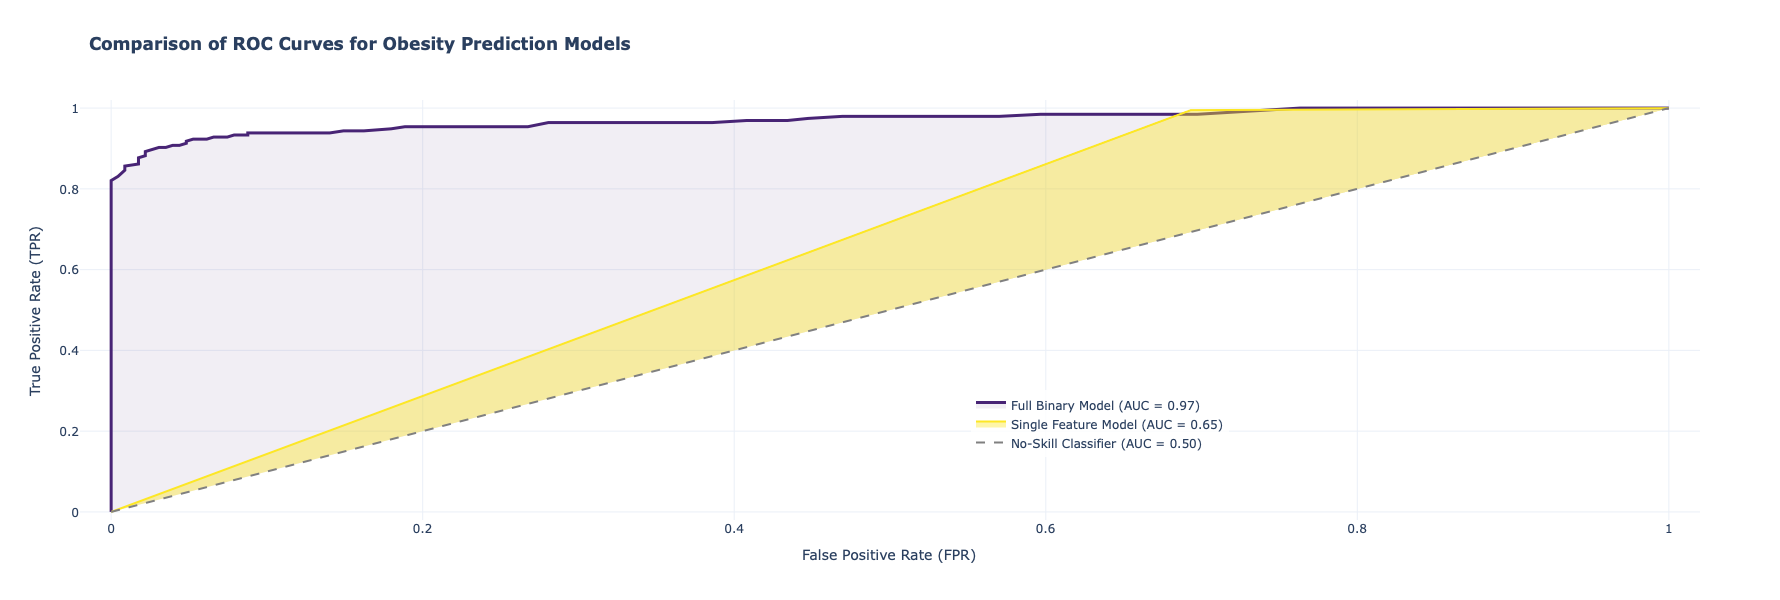

In [74]:
# Get FPR and TPR
fpr_full, tpr_full, _ = roc_curve(y_test_bin, y_pred_proba_bin)
roc_auc_full = auc(fpr_full, tpr_full)

fpr_single, tpr_single, _ = roc_curve(y_test_bin, y_pred_proba_single)
roc_auc_single = auc(fpr_single, tpr_single)

fig = go.Figure()

# Full Binary Model 
fig.add_trace(
    go.Scatter(
        x=fpr_full,
        y=tpr_full,
        mode='lines',
        name=f'Full Binary Model (AUC = {roc_auc_full:.2f})',
        line=dict(color='#482475', width=3),
        fill='toself',  
        fillcolor='rgb(72, 36, 117, 0.08)', 
    )
)

# Single Feature Model 
fig.add_trace(
    go.Scatter(
        x=fpr_single,
        y=tpr_single,
        mode='lines',
        name=f'Single Feature Model (AUC = {roc_auc_single:.2f})',
        line=dict(color='#fde725', width=2),
        fill='toself',
        fillcolor='rgb(253, 231, 37,0.4)',
        
    )
)

# No-Skill Classifier diagonal line
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode='lines',
        name='No-Skill Classifier (AUC = 0.50)',
        line=dict(color='gray', width=2, dash='dash'),
    )
)


fig.update_layout(
    title='<b>Comparison of ROC Curves for Obesity Prediction Models</b>',
    xaxis_title='False Positive Rate (FPR)',
    yaxis_title='True Positive Rate (TPR)',
    xaxis=dict(range=[-0.02, 1.02], zeroline=False),
    yaxis=dict(range=[-0.02, 1.02], zeroline=False),
    legend=dict(x=0.55, y=0.15, bgcolor='rgba(255, 255, 255, 0.8)'),
    template='plotly_white',
    width=800,
    height=600,
)

fig.show()

The receiver operating characteristic curve analysis shows that the full binary model achieves an exceptional area under the curve score of 0.97, indicating a near-perfect capability to distinguish between classes. In contrast, the single-feature baseline model yields an area under the curve score of 0.65, performing only moderately better than a random classifier at 0.50. Additionally, the shaded region highlights the substantial performance improvement gained by incorporating a comprehensive set of predictors rather than relying on just a single variable.

**MULTICLASS MODEL EVALUATION**

In [75]:
#Scale the data (Mandatory for SVMs and k-NN)
scaler_multi=StandardScaler()
X_train_multi_scaled=scaler_multi.fit_transform(X_train_multi)
X_test_multi_scaled=scaler_multi.transform(X_test_multi)

#Train the model Support vector machine
svm_multi=SVC(kernel='rbf', probability=True, random_state=42)
svm_multi.fit(X_train_multi_scaled,y_train_multi)
#Train the model k-nearest neighbor
knn_multi = KNeighborsClassifier(n_neighbors=5)
knn_multi.fit(X_train_multi_scaled, y_train_multi)

#Generate predictions
y_pred_svm_multi=svm_multi.predict(X_test_multi_scaled)

y_pred_knn_multi = knn_multi.predict(X_test_multi_scaled)
y_proba_knn_multi = knn_bin.predict_proba(X_test_multi_scaled)


print("--- SUPPORT VECTOR MACHINE (MULTICLASS) RESULTS ---")
print("Accuracy:", accuracy_score(y_test_multi, y_pred_svm_multi))
print(classification_report(y_test_multi, y_pred_svm_multi))


print('--- K-NEAREST NEIGHBORS (MULTICLASS) RESULTS ---')
print("Accuracy:", accuracy_score(y_test_multi, y_pred_knn_multi))
print(classification_report(y_test_multi, y_pred_knn_multi))

--- SUPPORT VECTOR MACHINE (MULTICLASS) RESULTS ---
Accuracy: 0.7446808510638298
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        54
           1       0.64      0.64      0.64        58
           2       0.56      0.62      0.59        58
           3       0.68      0.59      0.63        58
           4       0.73      0.63      0.68        70
           5       0.78      0.90      0.84        60
           6       0.98      0.97      0.98        65

    accuracy                           0.74       423
   macro avg       0.74      0.74      0.74       423
weighted avg       0.74      0.74      0.74       423

--- K-NEAREST NEIGHBORS (MULTICLASS) RESULTS ---
Accuracy: 0.7446808510638298
              precision    recall  f1-score   support

           0       0.72      0.93      0.81        54
           1       0.54      0.36      0.43        58
           2       0.62      0.62      0.62        58
           3       0.62    

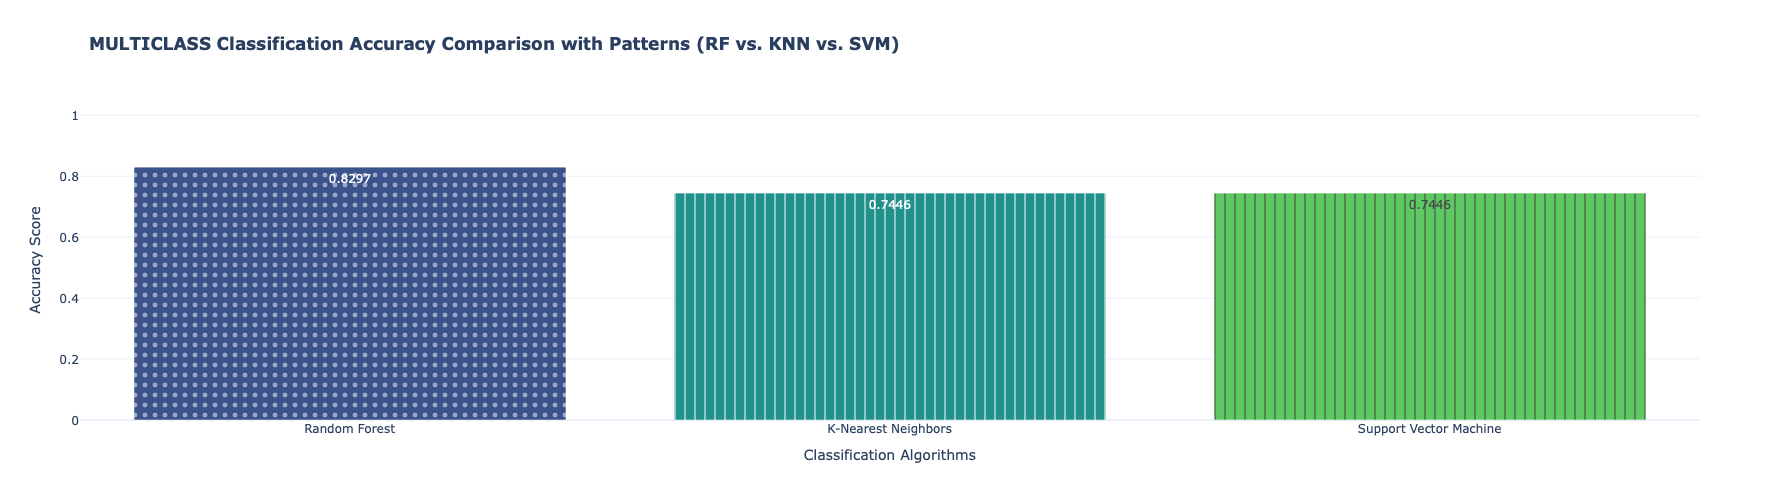

In [76]:
models = ["Random Forest", "K-Nearest Neighbors", "Support Vector Machine"]
accuracies = [0.8297, 0.7446, 0.7446]
colors = ["#3b528b", "#21918c", "#5ec962"] 

patterns = [".", "|","|"]

fig = go.Figure()

for model, acc, col, pat in zip(models, accuracies, colors, patterns):
  fig.add_trace(
      go.Bar(
          name=model,
          x=[model],
          y=[acc],
          marker=dict(
              color=col,
              pattern=dict(
                  shape=pat, fillmode="overlay"
              ),  
          ),
          text=[f"{acc:.4f}"],
          textposition="auto",
      )
  )

fig.update_layout(
    title=(
        "<b>MULTICLASS Classification Accuracy Comparison with Patterns (RF vs."
        " KNN vs. SVM)</b>"
    ),
    xaxis_title="Classification Algorithms",
    yaxis_title="Accuracy Score",
    yaxis=dict(range=[0, 1.05]),
    template="plotly_white",
    height=500,
    showlegend=False,
)

fig.show()

***Evaluating Model Classification Performance and Class Confusion via Confusion Matrix Visualization***

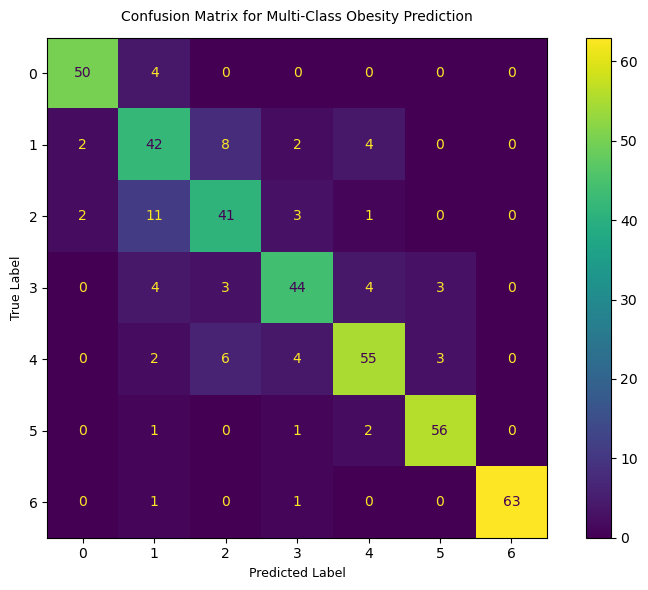

In [77]:

cm = confusion_matrix(y_test_multi, y_pred_multi)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=rf_multi.classes_
)
disp.plot(cmap='viridis', values_format='d', ax=plt.gca())


plt.title(
    'Confusion Matrix for Multi-Class Obesity Prediction', fontsize=10, pad=12
)
plt.xlabel('Predicted Label', fontsize=9)
plt.ylabel('True Label', fontsize=9)

plt.tight_layout()
plt.show()

The confusion matrix reveals that the multi-class random forest model achieves robust overall performance, with the vast majority of predictions correctly falling along the diagonal from top-left to bottom-right. Classes 0, 5, and 6 exhibit particularly high classification accuracy with minimal confusion, indicating the model reliably identifies these categories. However, noticeable misclassifications occur primarily between adjacent classes, such as instances where true class 2 samples were incorrectly predicted as class 1 eleven times. This pattern suggests that the model occasionally struggles to separate closely related intermediate categories, which is a common characteristic in ordinal or multi-level classification tasks like obesity risk grading.

In [78]:

rf = RandomForestClassifier(random_state=42)

# grid of hyperparameters to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

# initialize the search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,  
    scoring='accuracy',  
    n_jobs=-1,  
)

#Fit to training data
grid_search.fit(X_train_multi, y_train_multi)

# Output the best parameters and score
print('Best Parameters:', grid_search.best_params_)
print('Best Cross-Validation Score:', grid_search.best_score_)

best_rf_multi = grid_search.best_estimator_
y_pred_multi_tuned = best_rf_multi.predict(X_test_multi)

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Score: 0.8483398591821327


In [79]:
print("\n--- MULTI-CLASS CLASSIFICATION RESULTS AFTER HYPERPARAMETER TUNING ---")
print("Accuracy:", accuracy_score(y_test_multi, y_pred_multi_tuned))
print(classification_report(y_test_multi, y_pred_multi_tuned))


--- MULTI-CLASS CLASSIFICATION RESULTS AFTER HYPERPARAMETER TUNING ---
Accuracy: 0.83451536643026
              precision    recall  f1-score   support

           0       0.92      0.91      0.92        54
           1       0.64      0.76      0.69        58
           2       0.68      0.69      0.68        58
           3       0.88      0.76      0.81        58
           4       0.85      0.81      0.83        70
           5       0.90      0.93      0.92        60
           6       1.00      0.97      0.98        65

    accuracy                           0.83       423
   macro avg       0.84      0.83      0.83       423
weighted avg       0.84      0.83      0.84       423



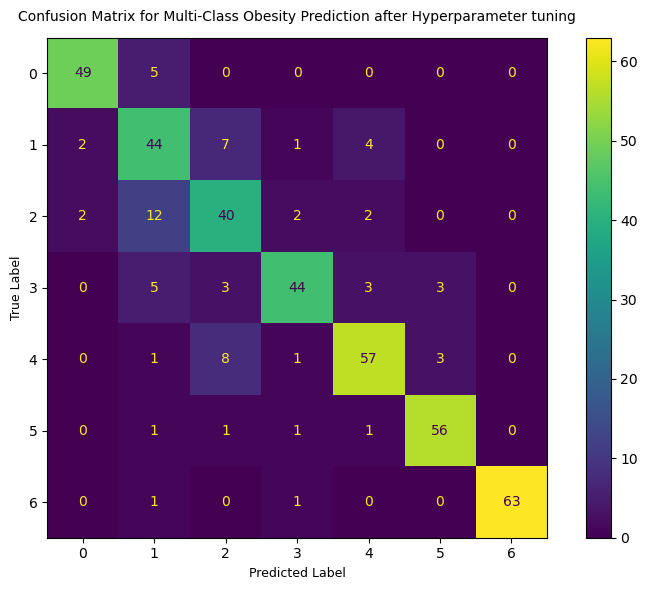

In [80]:
cm = confusion_matrix(y_test_multi, y_pred_multi_tuned)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=rf_multi.classes_
)
disp.plot(cmap='viridis', values_format='d', ax=plt.gca())


plt.title(
    'Confusion Matrix for Multi-Class Obesity Prediction after Hyperparameter tuning', fontsize=10, pad=12
)
plt.xlabel('Predicted Label', fontsize=9)
plt.ylabel('True Label', fontsize=9)

plt.tight_layout()
plt.show()

A comparison of the confusion matrices before and after hyperparameter tuning reveals that the random forest model's predictive behavior remained nearly identical. While tuning led to minor shifts in individual cell counts—such as slight variations in correct classifications for classes four and zero—the overarching error patterns and diagonal concentrations stayed consistent. This indicates that the default hyperparameters were already robustly capturing the underlying patterns in the dataset, meaning the tuning process optimized minor boundary conditions without fundamentally altering the model's structure or classification capability.

---

### Step 7 - Final results

> Binary Classification: Can we accurately predict whether someone falls into an 'Obese' category using a binary classification approach, and is family history alone sufficient to make that prediction?

The binary classification analysis successfully demonstrated that individuals can be accurately identified within the 'Obese' category utilizing a comprehensive feature set, yielding an exceptional AUC score of 0.97. This discriminative capability starkly contrasts with the single-feature baseline model relying strictly on family history, which achieved a modest AUC of 0.65 —performing only marginally better than a random guess. Consequently, while family history serves as a critical genetic and environmental predisposition, it is fundamentally insufficient on its own for reliable classification. This confirms that robust predictive modeling requires a multidimensional approach rather than dependence on a single isolated variable.

> Multi-Class Classification: Can we accurately predict an individual's obesity level category (NObeyesdad) based on their eating habits and physical condition?

The multi-class classification investigated whether an individual's specific obesity level (NObeyesdad) could be effectively predicted using behavioral and physiological attributes, such as eating habits and physical condition. The random forest architecture achieved a strong overall accuracy of 0.83 (with a macro average of 0.84).
An examination of the class-specific metrics and confusion matrices reveals clear structural patterns in how the model operates:
In addition,he model excels at identifying distinct demographic or physiological extremes—such as the highest severity category (like Underweight(0) or Obesity Level II(5) and Obesity level III(6)— exhibiting near-optimal precision and recall. Misclassifications are heavily concentrated among adjacent, intermediate categories (such as true class 2(Overweight I) instances occasionally being predicted as class 1(Normal)); reflecting the continuous and overlapping nature of clinical obesity grading, where definitions between neighboring weight categories are subtle.

Moreover, comparative analysis against a hyperparameter-tuned model demonstrated virtually identical predictive distributions and error patterns, with test accuracy remaining stable at ~0.83. This confirms that the default random forest configuration was already robustly optimized to capture the complex, underlying multi-class boundaries without suffering from severe structural bias or overfitting.


---
    This work was produced for the final assessment of the course in Applied Machine Learning(Basic) at UniBo MSc in Bioinformatics
    © 2026 [Visani Alessia]. All rights reserved.
    